# Model PC feature visualization

Visualize the coordinates already stored by the frame-PCA feature pipeline. No model inference or additional PCA is performed here.

The notebook provides three views:

1. the final frame of every movie on two configurable stored PC axes, for every layer of one model;
2. the bottom and top unique-frame extremes of PCs 1–10, for every layer;
3. a denser view of one configurable model/layer using evenly spaced frames from every movie.

PC indices in `Cfg` are zero-based: `(0, 1)` displays PC 1 against PC 2.

## Setup

In [1]:
from dataclasses import dataclass
import os
from pathlib import Path
import sys

import cv2
import h5py
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
import numpy as np
import yaml

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = next(
    parent
    for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (parent / "config.yaml").exists()
)

with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
# end with open

paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from image_processing.video_feature_extraction import list_video_feature_files

## Configuration

`model_name` controls the all-layer plots. Set `target_model_name` and `target_layer_name` only when the dense view should inspect a different model or a specific layer; `None` selects the all-layer model and its deepest available layer.

In [16]:
@dataclass
class Cfg:
    # Model whose complete layer hierarchy is visualized.
    model_name: str = "alexnet"
    dataset_name: str = "static_dynamic"
    n_components: int = 1000
    # Stored PC columns shown on x and y; these indices are zero-based.
    pc_indices: tuple[int, int] = (1, 2)

    # Optional cap for a quick test; None processes every model layer.
    max_layers: int | None = None
    # Number of PCs and images per tail in each layer's extreme grid.
    n_extreme_pcs: int = 10
    n_extreme_frames: int = 5

    # Model/layer inspected with several frames from every movie.
    target_model_name: str | None = None
    target_layer_name: str | None = None
    dense_frames_per_video: int = 10

    # Visualization and adjacent-upsampled-frame deduplication controls.
    thumbnail_size: int = 64
    duplicate_mae_threshold: float = 0.25
    # Increase or decrease these values to resize scatterplot thumbnails.
    last_frame_scatter_image_size: float = 0.5
    dense_scatter_image_size: float = 0.40
    # Dense thumbnail opacity: 0.0 is transparent and 1.0 is opaque.
    dense_scatter_image_alpha: float = 0.60

    # Defaults resolve from config.yaml when left as None.
    feature_dir: str | None = None
    stimuli_dir: str | None = None


cfg = Cfg()
cfg

Cfg(model_name='alexnet', dataset_name='static_dynamic', n_components=1000, pc_indices=(1, 2), max_layers=None, n_extreme_pcs=10, n_extreme_frames=5, target_model_name=None, target_layer_name=None, dense_frames_per_video=10, thumbnail_size=64, duplicate_mae_threshold=0.25, last_frame_scatter_image_size=0.5, dense_scatter_image_size=0.4, dense_scatter_image_alpha=0.6, feature_dir=None, stimuli_dir=None)

## Loading, deduplication, and plotting functions

All visualization code is defined directly in this notebook. The only project utility imported above is the existing feature-file locator.

In [20]:
@dataclass
class FrameCatalog:
    video_names: list[str]
    source_paths: list[Path]
    frame_counts: np.ndarray
    video_indices: np.ndarray
    frame_indices: np.ndarray
    images: np.ndarray
    unique_mask: np.ndarray

    @property
    def video_starts(self):
        return np.concatenate(([0], np.cumsum(self.frame_counts)[:-1]))

    @property
    def last_frame_indices(self):
        return self.video_starts + self.frame_counts - 1
    # EOF


"""
decode_video_thumbnails
Decode the feature-aligned frames of one movie and mark adjacent duplicates.

INPUT:
    - video_path: str | Path -> source movie
    - expected_frames: int -> number of feature rows to match
    - frame_stride: int -> decoded-frame stride used during extraction
    - thumbnail_size: int -> square RGB thumbnail size
    - duplicate_mae_threshold: float -> maximum grayscale MAE for a duplicate

OUTPUT:
    - images: np.ndarray -> feature-aligned RGB thumbnails
    - unique_mask: np.ndarray -> first frame of each adjacent duplicate run
"""
def decode_video_thumbnails(
        video_path, expected_frames, frame_stride, thumbnail_size,
        duplicate_mae_threshold,
        ):
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    # end if video could not be opened

    images = []
    unique_mask = []
    previous_gray = None
    decoded_frame_index = 0
    try:
        while len(images) < expected_frames:
            ok, frame_bgr = capture.read()
            if not ok:
                break
            # end if video ended
            if decoded_frame_index % frame_stride == 0:
                frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
                thumbnail = cv2.resize(
                    frame_rgb, (thumbnail_size, thumbnail_size),
                    interpolation=cv2.INTER_AREA,
                )
                gray = cv2.cvtColor(
                    thumbnail, cv2.COLOR_RGB2GRAY,
                ).astype(np.float32)
                is_unique = previous_gray is None
                if previous_gray is not None:
                    frame_mae = float(np.mean(np.abs(gray - previous_gray)))
                    is_unique = frame_mae > duplicate_mae_threshold
                # end if previous frame exists
                images.append(thumbnail)
                unique_mask.append(is_unique)
                previous_gray = gray
            # end if retained frame
            decoded_frame_index += 1
        # end while
    finally:
        capture.release()
    # end try

    if len(images) != expected_frames:
        raise RuntimeError(
            f"Decoded {len(images)} frames from {Path(video_path).name}; "
            f"expected {expected_frames}."
        )
    # end if frame count mismatch
    return np.stack(images), np.asarray(unique_mask, dtype=bool)
# EOF


"""
build_frame_catalog
Build a model-independent image catalog aligned with every HDF5 feature row.

INPUT:
    - feature_path: str | Path -> reference layer PC-pooled HDF5 file
    - stimuli_dir: str | Path -> fallback source-video directory
    - thumbnail_size: int -> square RGB thumbnail size
    - duplicate_mae_threshold: float -> adjacent-frame duplicate cutoff

OUTPUT:
    - catalog: FrameCatalog -> aligned thumbnails and frame identities
"""
def build_frame_catalog(
        feature_path, stimuli_dir, thumbnail_size=64,
        duplicate_mae_threshold=0.25,
        ):
    with h5py.File(feature_path, "r") as feature_file:
        video_names = list(feature_file.keys())
        frame_stride = int(feature_file.attrs.get("frame_stride", 1))
        frame_counts = np.asarray([
            feature_file[name].shape[0] for name in video_names
        ], dtype=int)
        source_paths = [
            Path(feature_file[name].attrs.get("source_path", name))
            for name in video_names
        ]
    # end with h5py.File

    # Use the configured stimulus directory if the stored machine path moved.
    source_paths = [
        path if path.exists() else Path(stimuli_dir) / video_name
        for path, video_name in zip(source_paths, video_names, strict=True)
    ]
    missing_paths = [path for path in source_paths if not path.exists()]
    if missing_paths:
        raise FileNotFoundError(f"Missing source video: {missing_paths[0]}")
    # end if source video is missing

    all_images = []
    all_unique_masks = []
    all_video_indices = []
    all_frame_indices = []
    for video_index, (video_path, frame_count) in enumerate(zip(
            source_paths, frame_counts, strict=True,
            )):
        images, unique_mask = decode_video_thumbnails(
            video_path, int(frame_count), frame_stride, thumbnail_size,
            duplicate_mae_threshold,
        )
        all_images.append(images)
        all_unique_masks.append(unique_mask)
        all_video_indices.append(np.full(frame_count, video_index, dtype=int))
        all_frame_indices.append(np.arange(frame_count, dtype=int))
    # end for video

    return FrameCatalog(
        video_names=video_names,
        source_paths=source_paths,
        frame_counts=frame_counts,
        video_indices=np.concatenate(all_video_indices),
        frame_indices=np.concatenate(all_frame_indices),
        images=np.concatenate(all_images),
        unique_mask=np.concatenate(all_unique_masks),
    )
# EOF


"""
load_pc_scores
Load only selected stored PC columns while preserving catalog row order.

INPUT:
    - feature_path: str | Path -> layer-specific PC-pooled HDF5 file
    - catalog: FrameCatalog -> reference stimulus and frame order
    - pc_indices: iterable[int] -> zero-based PC columns to load

OUTPUT:
    - scores: np.ndarray -> frames x selected PCs
    - layer_name: str -> layer identity stored in the file
"""
def load_pc_scores(feature_path, catalog, pc_indices):
    pc_indices = np.asarray(tuple(pc_indices), dtype=int)
    if np.any(pc_indices < 0) or len(np.unique(pc_indices)) != len(pc_indices):
        raise ValueError("PC indices must be unique and non-negative.")
    # end if invalid PC indices
    sorted_order = np.argsort(pc_indices)
    sorted_indices = pc_indices[sorted_order]
    restore_order = np.argsort(sorted_order)

    layer_scores = []
    with h5py.File(feature_path, "r") as feature_file:
        if list(feature_file.keys()) != catalog.video_names:
            raise ValueError(f"Stimulus order differs in {feature_path}.")
        # end if stimulus order differs
        layer_name = str(feature_file.attrs["layer_name"])
        for video_name, frame_count in zip(
                catalog.video_names, catalog.frame_counts, strict=True,
                ):
            dataset = feature_file[video_name]
            if dataset.shape[0] != frame_count:
                raise ValueError(f"Frame count differs for {video_name}.")
            if sorted_indices[-1] >= dataset.shape[1]:
                raise IndexError(
                    f"PC {sorted_indices[-1] + 1} is unavailable in {layer_name}."
                )
            # end if PC is unavailable
            layer_scores.append(dataset[:, sorted_indices][:, restore_order])
        # end for video
    # end with h5py.File
    return np.concatenate(layer_scores), layer_name
# EOF


"""
select_even_unique_frames
Select approximately evenly spaced non-duplicate frames from every movie.

INPUT:
    - catalog: FrameCatalog -> aligned frame identities and uniqueness mask
    - frames_per_video: int -> requested frames from each movie

OUTPUT:
    - selected_indices: np.ndarray -> global catalog row indices
"""
def select_even_unique_frames(catalog, frames_per_video=10):
    selected_indices = []
    for video_index in range(len(catalog.video_names)):
        candidates = np.flatnonzero(
            (catalog.video_indices == video_index) & catalog.unique_mask
        )
        positions = np.linspace(
            0, len(candidates) - 1, min(frames_per_video, len(candidates)),
        )
        selected_indices.extend(candidates[np.rint(positions).astype(int)])
    # end for video
    return np.asarray(selected_indices, dtype=int)
# EOF


"""
get_pc_extreme_indices
Find low and high extremes with at most one selected frame per source movie.

INPUT:
    - scores: np.ndarray -> frames x PCs
    - unique_mask: np.ndarray -> candidate frames after duplicate removal
    - video_indices: np.ndarray -> source-movie index of every frame
    - n_extreme: int -> frames retained in each tail

OUTPUT:
    - bottom_indices: np.ndarray -> PCs x n_extreme, ascending score
    - top_indices: np.ndarray -> PCs x n_extreme, descending score
"""
def get_pc_extreme_indices(
        scores, unique_mask, video_indices, n_extreme=5,
        ):
    candidate_indices = np.flatnonzero(unique_mask)
    candidate_video_count = len(np.unique(video_indices[candidate_indices]))
    if candidate_video_count < 2 * n_extreme:
        raise ValueError(
            f"Need {2 * n_extreme} source movies for two diverse tails; "
            f"found {candidate_video_count}."
        )
    # end if too few source movies

    bottom_indices = []
    top_indices = []
    for pc_index in range(scores.shape[1]):
        order = np.argsort(scores[candidate_indices, pc_index])
        sorted_candidates = candidate_indices[order]
        used_video_indices = set()
        pc_bottom_indices = []
        pc_top_indices = []

        # Keep the lowest-scoring frame from each newly encountered movie.
        for frame_index in sorted_candidates:
            video_index = int(video_indices[frame_index])
            if video_index not in used_video_indices:
                pc_bottom_indices.append(frame_index)
                used_video_indices.add(video_index)
            # end if movie is new
            if len(pc_bottom_indices) == n_extreme:
                break
            # end if bottom tail is complete
        # end for frame_index

        # Build the high tail from different movies than the low tail.
        for frame_index in sorted_candidates[::-1]:
            video_index = int(video_indices[frame_index])
            if video_index not in used_video_indices:
                pc_top_indices.append(frame_index)
                used_video_indices.add(video_index)
            # end if movie is new
            if len(pc_top_indices) == n_extreme:
                break
            # end if top tail is complete
        # end for frame_index

        bottom_indices.append(pc_bottom_indices)
        top_indices.append(pc_top_indices)
    # end for PC
    return np.stack(bottom_indices), np.stack(top_indices)
# EOF


"""
plot_image_scatter
Plot two PC coordinates with their aligned image thumbnails overlaid.

INPUT:
    - coordinates: np.ndarray -> samples x 2 selected PC scores
    - images: np.ndarray -> aligned RGB thumbnails
    - pc_indices: tuple[int, int] -> zero-based PCs shown on x and y
    - title: str -> figure title
    - image_zoom: float -> thumbnail scale
    - image_alpha: float -> thumbnail opacity from 0.0 to 1.0
    - figsize: tuple[float, float] -> figure size in inches

OUTPUT:
    - fig: matplotlib.figure.Figure -> completed figure
    - ax: matplotlib.axes.Axes -> scatterplot axis
"""
def plot_image_scatter(
        coordinates, images, pc_indices, title, image_zoom=0.22,
        image_alpha=1.0, figsize=(9, 9),
        ):
    if not 0.0 <= image_alpha <= 1.0:
        raise ValueError("image_alpha must be between 0.0 and 1.0.")
    # end if invalid image_alpha
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(
        coordinates[:, 0], coordinates[:, 1],
        s=12, c="0.35", alpha=0.60, linewidths=0, zorder=1,
    )
    for coordinate, image in zip(coordinates, images, strict=True):
        image_box = OffsetImage(
            image, zoom=image_zoom, alpha=image_alpha,
        )
        ax.add_artist(AnnotationBbox(
            image_box, coordinate, frameon=False, pad=0, zorder=2,
        ))
    # end for image
    ax.set_xlabel(f"PC {pc_indices[0] + 1} score")
    ax.set_ylabel(f"PC {pc_indices[1] + 1} score")
    ax.set_title(title)
    ax.margins(0.08)
    fig.tight_layout()
    return fig, ax
# EOF


"""
plot_pc_extremes
Show bottom and top image extremes for several stored PCs.

INPUT:
    - scores: np.ndarray -> frames x displayed PCs
    - images: np.ndarray -> aligned RGB thumbnails
    - bottom_indices: np.ndarray -> PCs x low-tail frame indices
    - top_indices: np.ndarray -> PCs x high-tail frame indices
    - layer_name: str -> title label

OUTPUT:
    - fig: matplotlib.figure.Figure -> completed image grid
    - axes: np.ndarray -> grid of image axes
"""
def plot_pc_extremes(
        scores, images, bottom_indices, top_indices, layer_name,
        ):
    n_pcs, n_extreme = bottom_indices.shape
    fig, axes = plt.subplots(
        n_pcs, 2 * n_extreme,
        figsize=(2.0 * n_extreme, 1.55 * n_pcs), squeeze=False,
    )
    for pc_index in range(n_pcs):
        display_indices = np.concatenate([
            bottom_indices[pc_index], top_indices[pc_index],
        ])
        for column_index, frame_index in enumerate(display_indices):
            ax = axes[pc_index, column_index]
            ax.imshow(images[frame_index])
            ax.set_title(
                f"{scores[frame_index, pc_index]:.2f}", fontsize=7, pad=2,
            )
            ax.axis("off")
        # end for column
        axes[pc_index, 0].text(
            -0.18, 0.5, f"PC {pc_index + 1}",
            transform=axes[pc_index, 0].transAxes,
            ha="right", va="center", fontsize=9, clip_on=False,
        )
    # end for PC

    for column_index in range(n_extreme):
        axes[0, column_index].text(
            0.5, 1.30, f"bottom {column_index + 1}",
            transform=axes[0, column_index].transAxes,
            ha="center", va="bottom", fontsize=8,
        )
        axes[0, n_extreme + column_index].text(
            0.5, 1.30, f"top {column_index + 1}",
            transform=axes[0, n_extreme + column_index].transAxes,
            ha="center", va="bottom", fontsize=8,
        )
    # end for column
    fig.suptitle(f"{layer_name}: unique-frame PC extremes", y=1.002)
    fig.tight_layout()
    return fig, axes
# EOF

## Resolve feature files

Layer order comes from `MODEL_ZOO`, not filename sorting. The notebook reads only the selected PC columns from each HDF5 file.

In [19]:
feature_dir = Path(cfg.feature_dir or Path(paths["data_path"]) / "models")
stimuli_dir = Path(
    cfg.stimuli_dir
    or Path(paths["data_path"]) / "stimuli" / "static_dynamic_videos"
)
pooling = f"PC{cfg.n_components}"

feature_paths = list_video_feature_files(
    feature_dir, cfg.model_name, cfg.dataset_name, pooling=pooling,
)
if cfg.max_layers is not None:
    feature_paths = feature_paths[:cfg.max_layers]
# end if max_layers

target_model_name = cfg.target_model_name or cfg.model_name
target_feature_paths = list_video_feature_files(
    feature_dir, target_model_name, cfg.dataset_name, pooling=pooling,
)
target_paths_by_layer = {}
for feature_path in target_feature_paths:
    with h5py.File(feature_path, "r") as feature_file:
        target_paths_by_layer[str(feature_file.attrs["layer_name"])] = feature_path
    # end with h5py.File
# end for feature_path

target_layer_name = cfg.target_layer_name or next(reversed(target_paths_by_layer))
if target_layer_name not in target_paths_by_layer:
    raise KeyError(
        f"Unknown target layer {target_layer_name!r}; choose one of "
        f"{list(target_paths_by_layer)}"
    )
# end if target layer is unavailable
target_feature_path = target_paths_by_layer[target_layer_name]

print(f"All-layer model: {cfg.model_name} ({len(feature_paths)} layers)")
print(f"Dense target: {target_model_name} / {target_layer_name}")
print(f"Feature pooling: {pooling}")

All-layer model: alexnet (7 layers)
Dense target: alexnet / classifier.5
Feature pooling: PC1000


## Build the shared image catalog

Every feature row is aligned to a decoded RGB thumbnail once. Adjacent frames whose thumbnail grayscale mean absolute difference is at or below `duplicate_mae_threshold` are treated as upsampling duplicates. Only the first frame in each duplicate run remains eligible for extreme or dense sampling; final-frame plots still retain one frame per movie.

In [5]:
catalog = build_frame_catalog(
    feature_paths[0],
    stimuli_dir=stimuli_dir,
    thumbnail_size=cfg.thumbnail_size,
    duplicate_mae_threshold=cfg.duplicate_mae_threshold,
)

n_total_frames = len(catalog.images)
n_unique_frames = int(catalog.unique_mask.sum())
print(f"Videos: {len(catalog.video_names)}")
print(f"Frames: {n_total_frames:,}")
print(f"Unique frames: {n_unique_frames:,}")
print(f"Excluded adjacent duplicates: {n_total_frames - n_unique_frames:,}")

Videos: 100
Frames: 18,000
Unique frames: 9,357
Excluded adjacent duplicates: 8,643


## Final movie frames across every layer

Each figure uses exactly one final frame per movie. The gray points preserve the numerical scatter underneath the thumbnails.

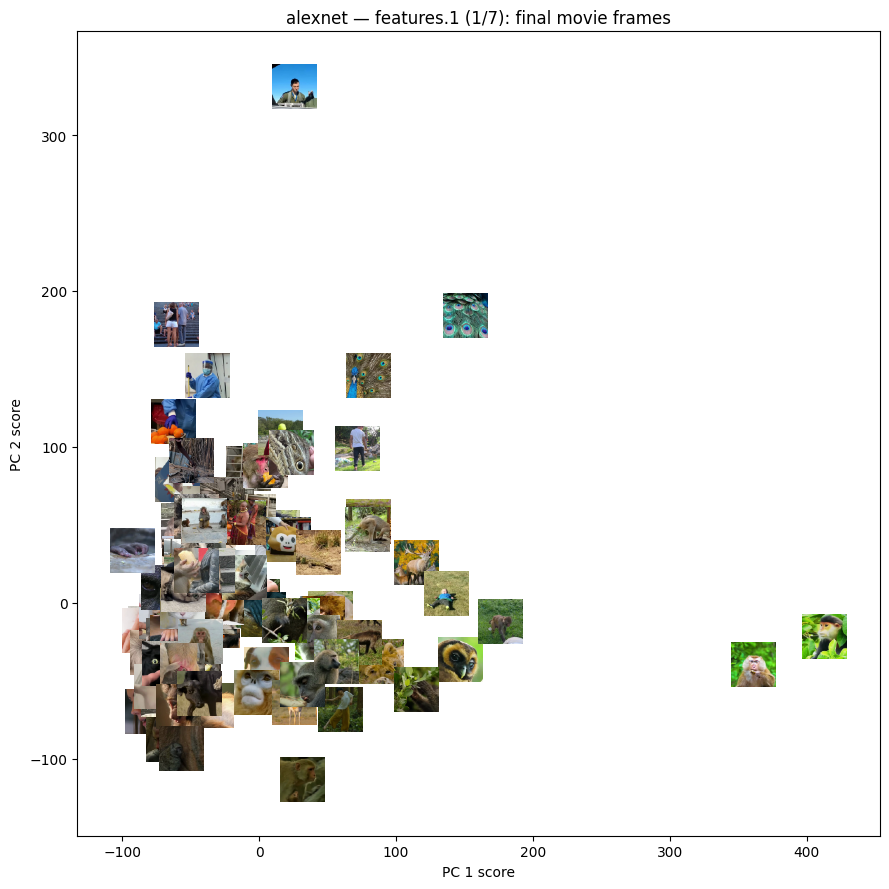

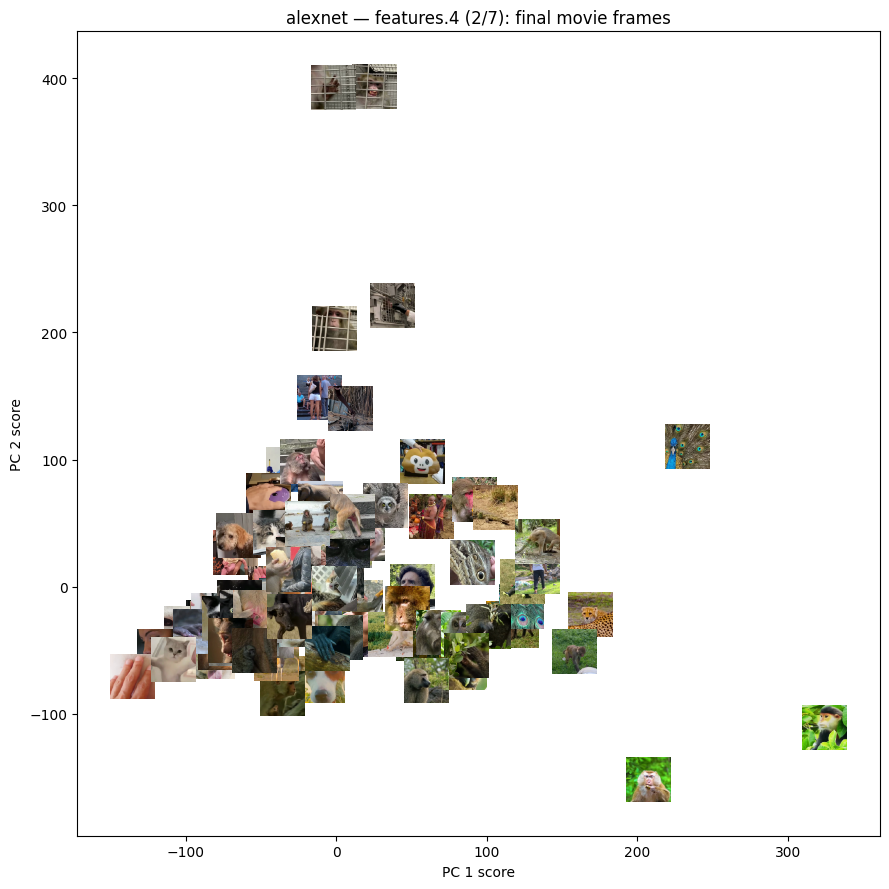

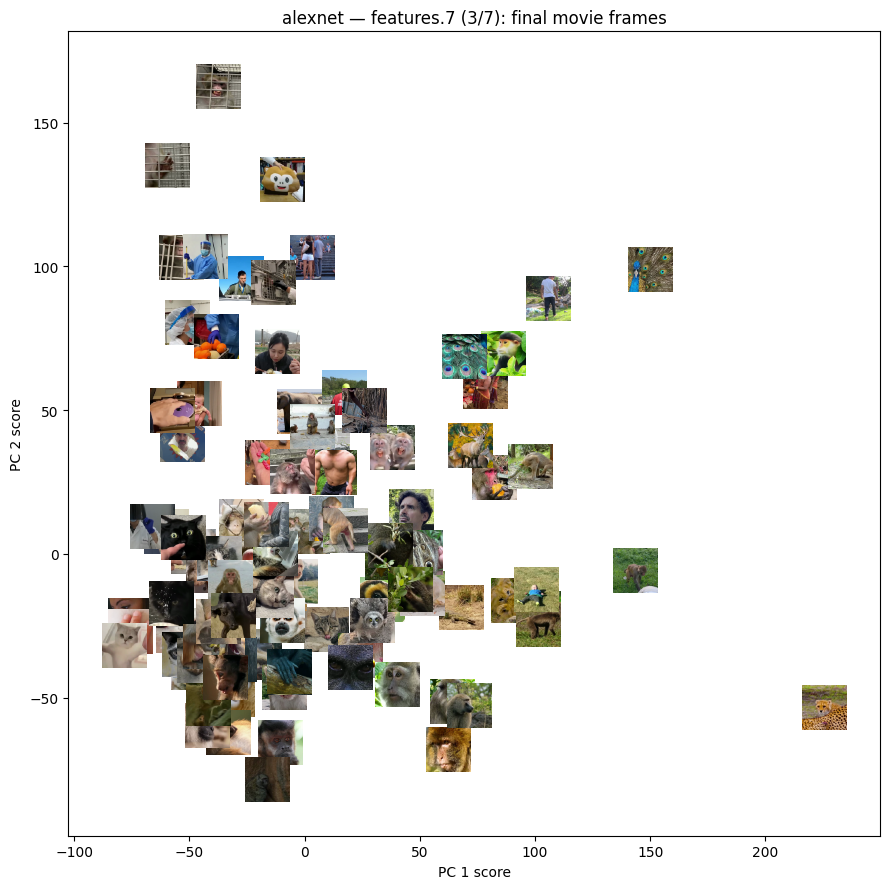

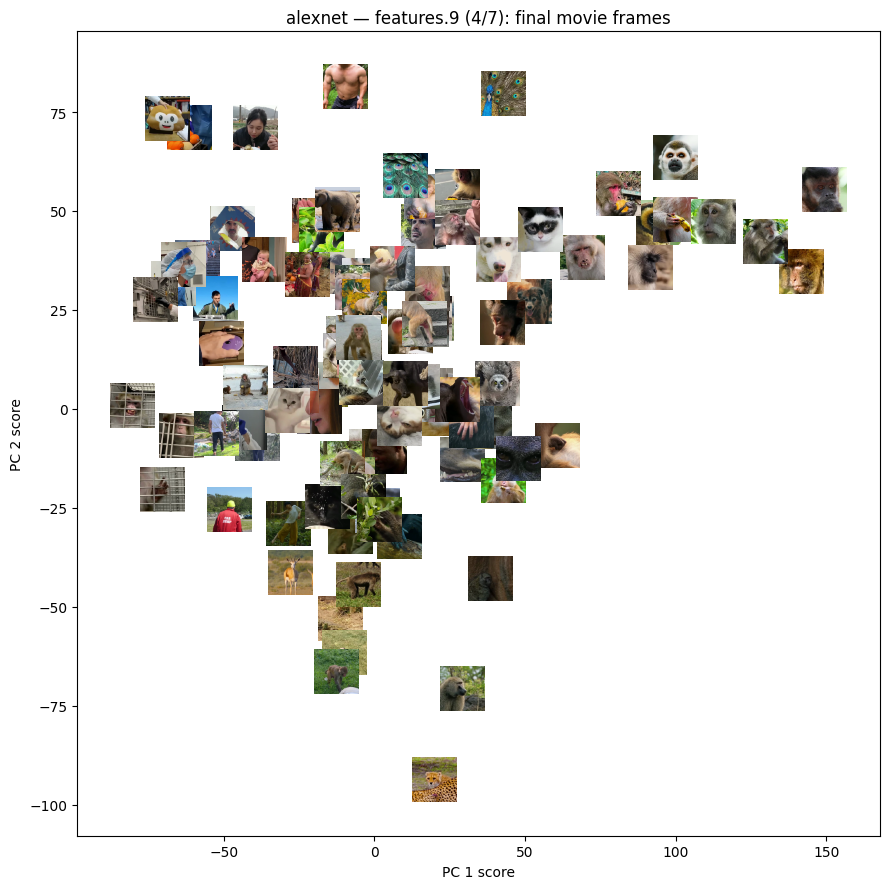

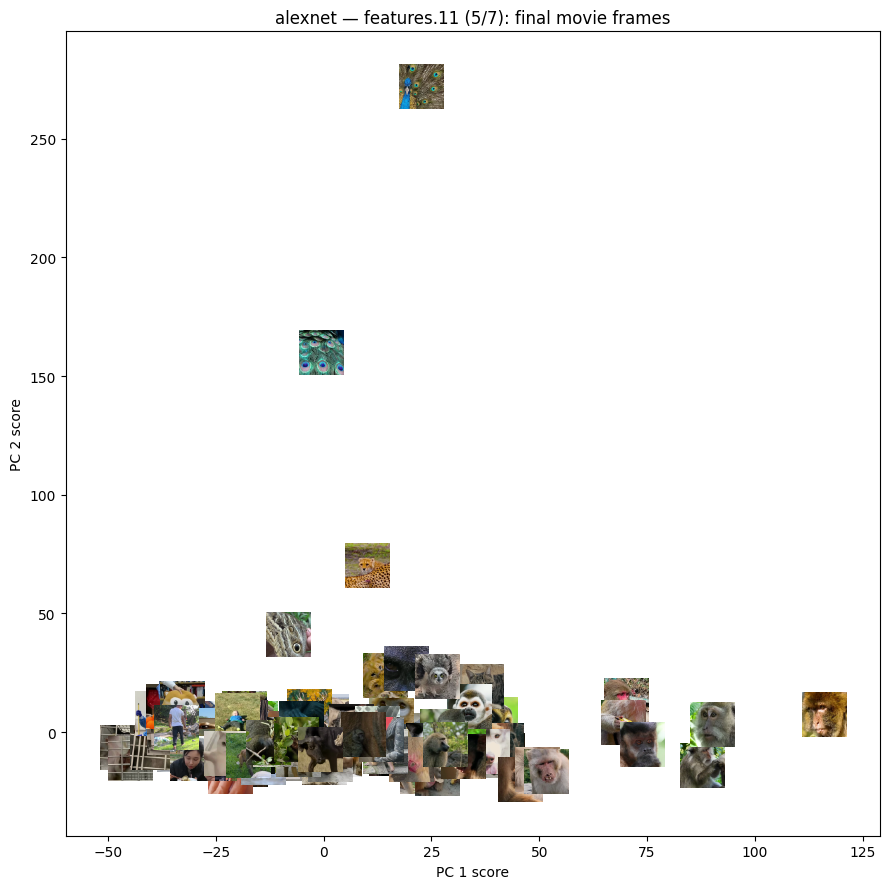

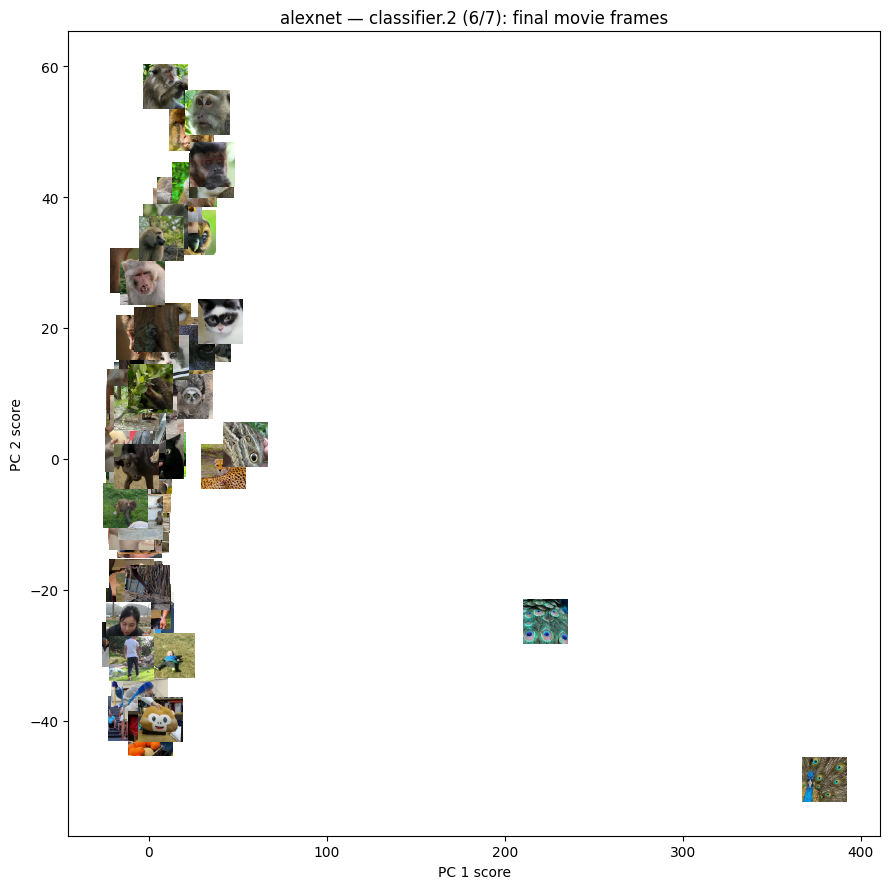

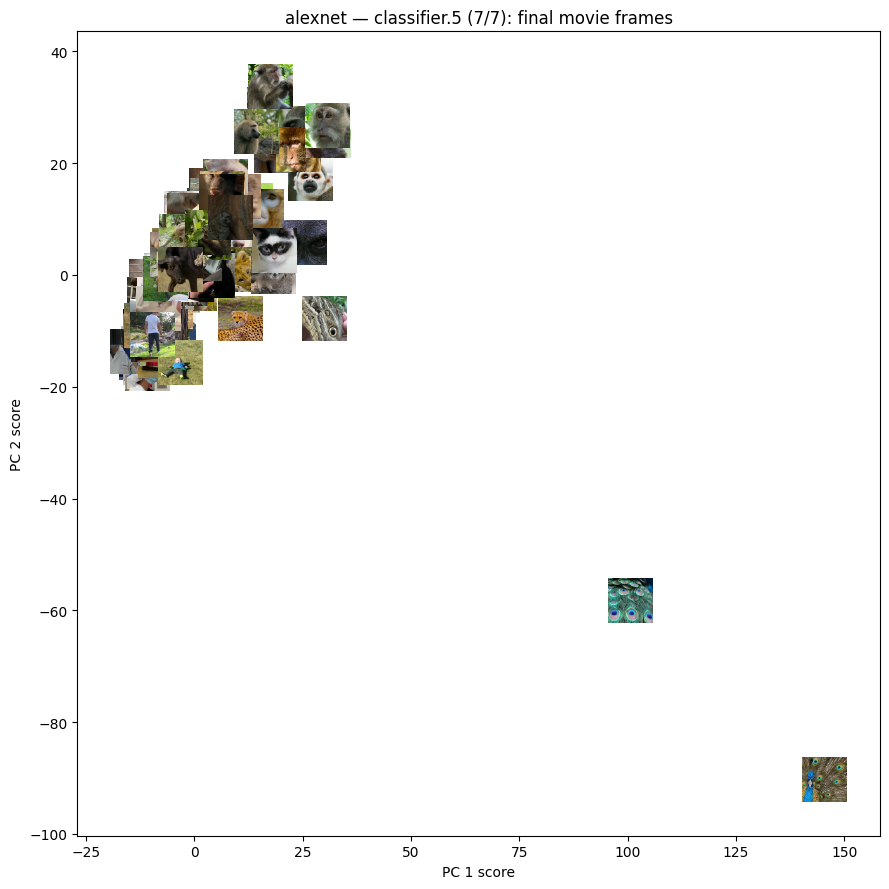

In [6]:
last_frame_indices = catalog.last_frame_indices
for layer_index, feature_path in enumerate(feature_paths, start=1):
    scores, layer_name = load_pc_scores(
        feature_path, catalog, cfg.pc_indices,
    )
    fig, _ = plot_image_scatter(
        coordinates=scores[last_frame_indices],
        images=catalog.images[last_frame_indices],
        pc_indices=cfg.pc_indices,
        title=(
            f"{cfg.model_name} — {layer_name} "
            f"({layer_index}/{len(feature_paths)}): final movie frames"
        ),
        image_zoom=cfg.last_frame_scatter_image_size,
    )
    plt.show()
    plt.close(fig)
# end for feature_path

## Unique-frame extremes of PCs 1–10 across every layer

Scores are compared over all frames of all movies after adjacent duplicate removal. Each PC row contains at most one frame from any source movie across both tails, preventing one movie from dominating the examples. Rows are PCs; the left half contains the lowest scores in ascending order and the right half the highest scores in descending order. Values above images are the stored PC scores.

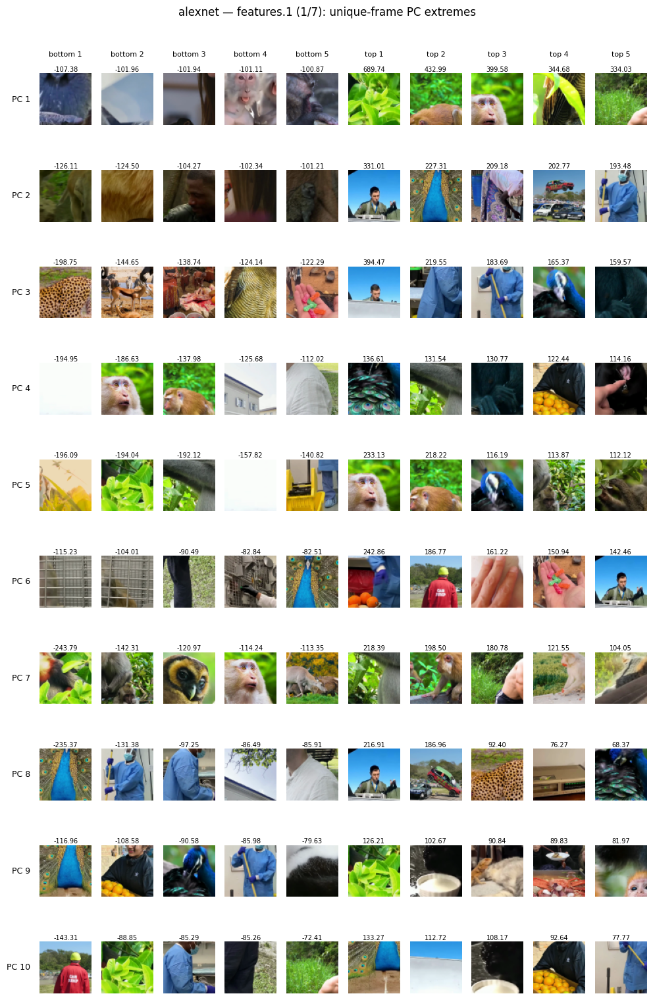

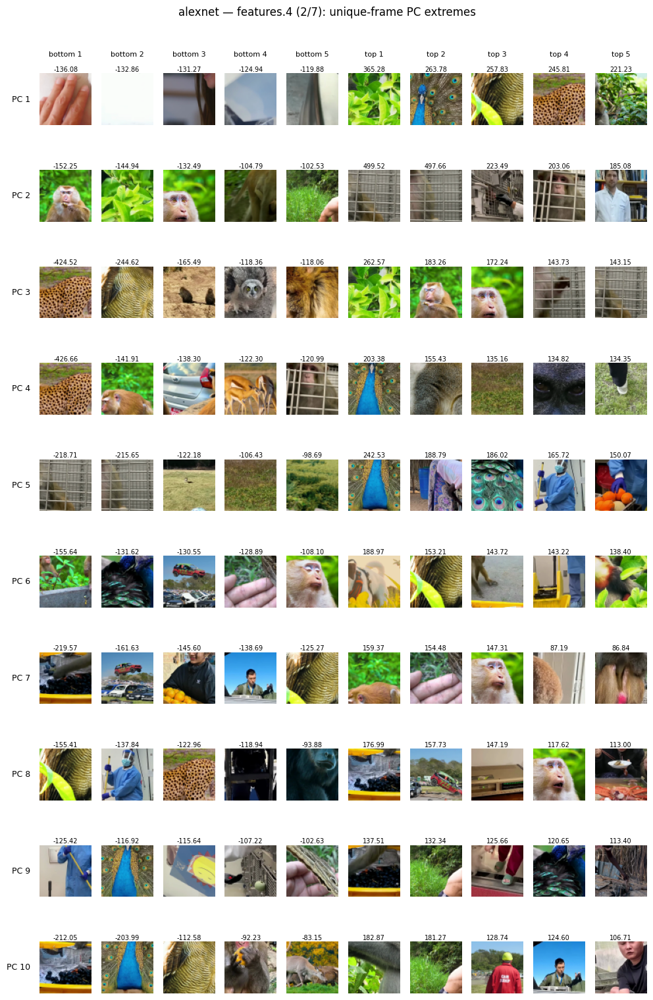

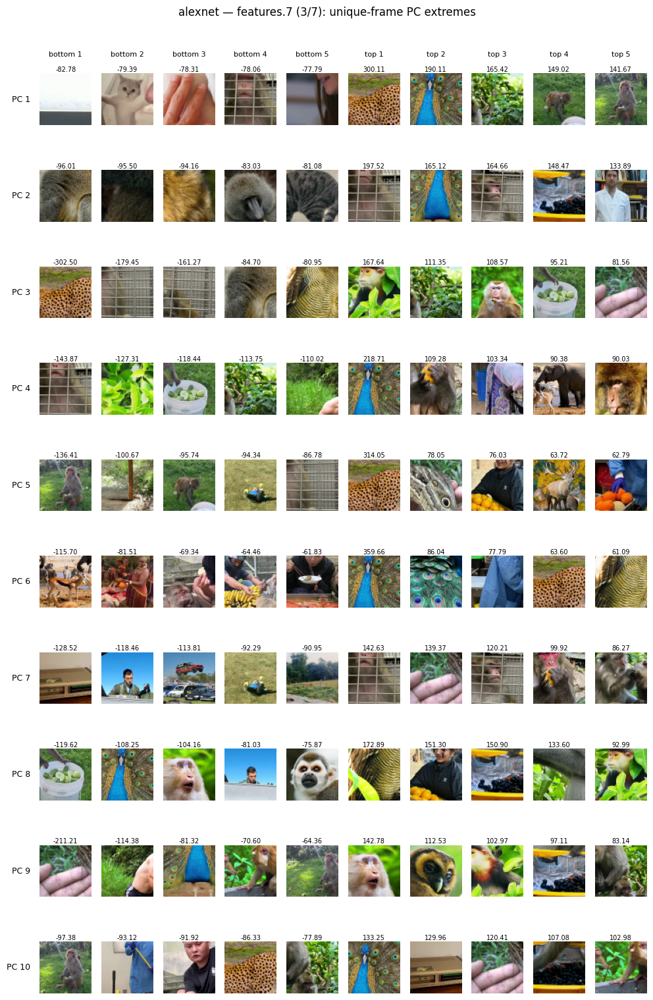

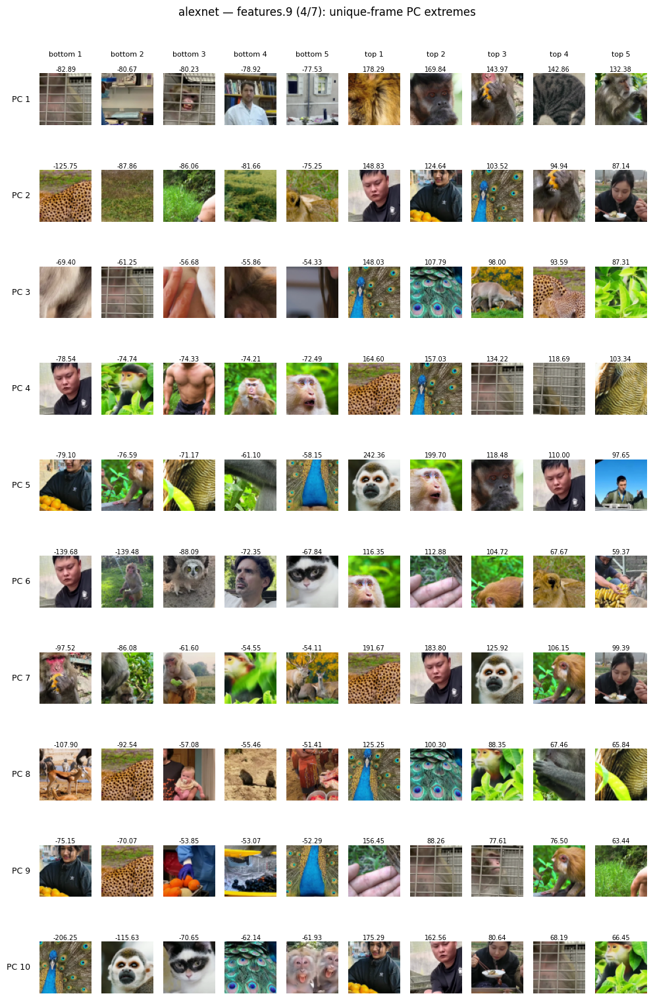

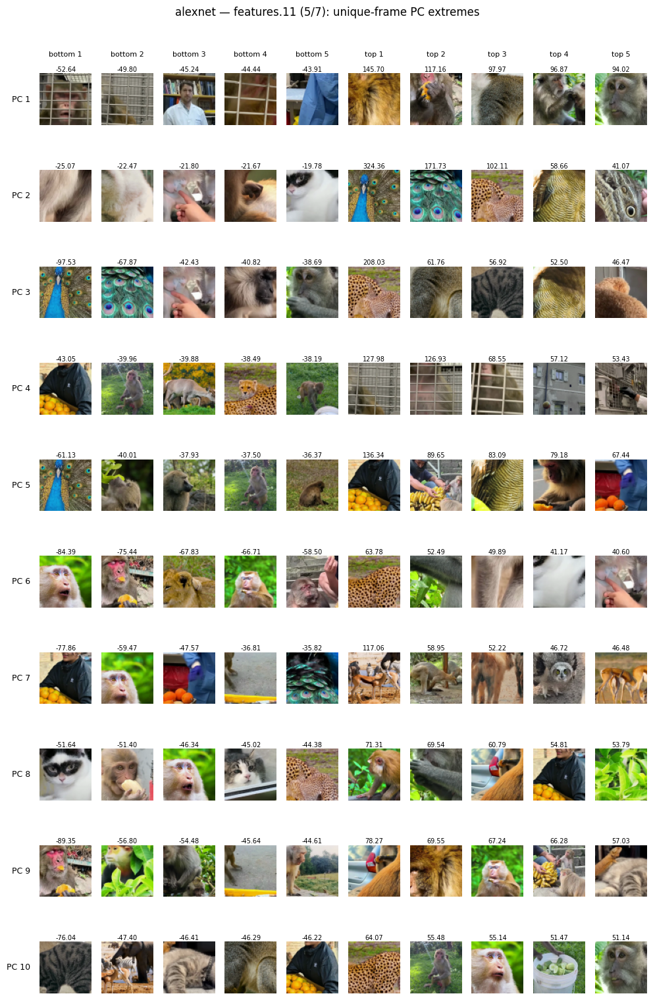

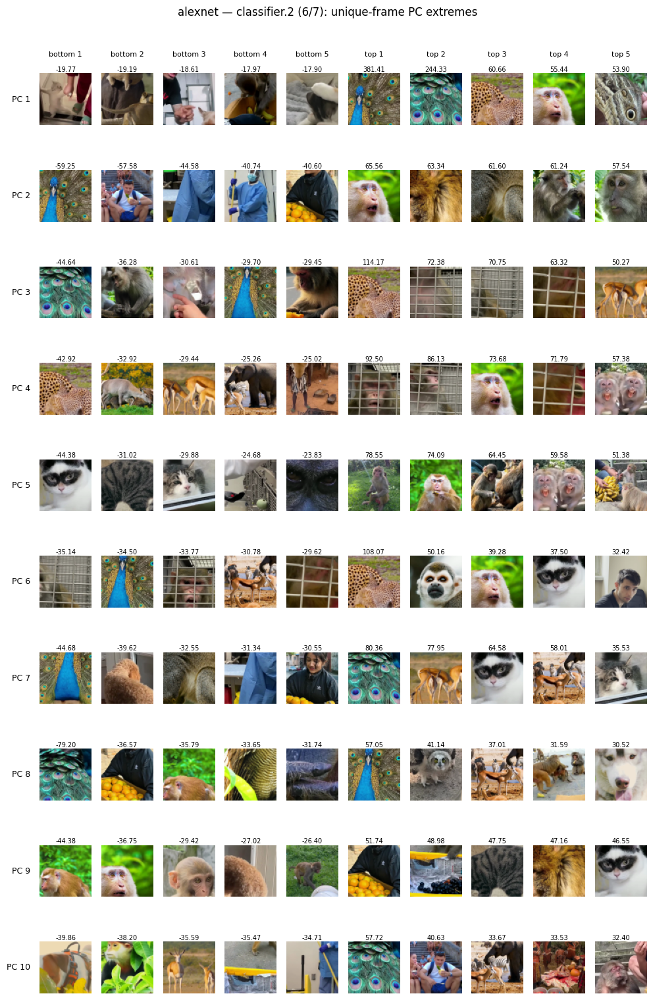

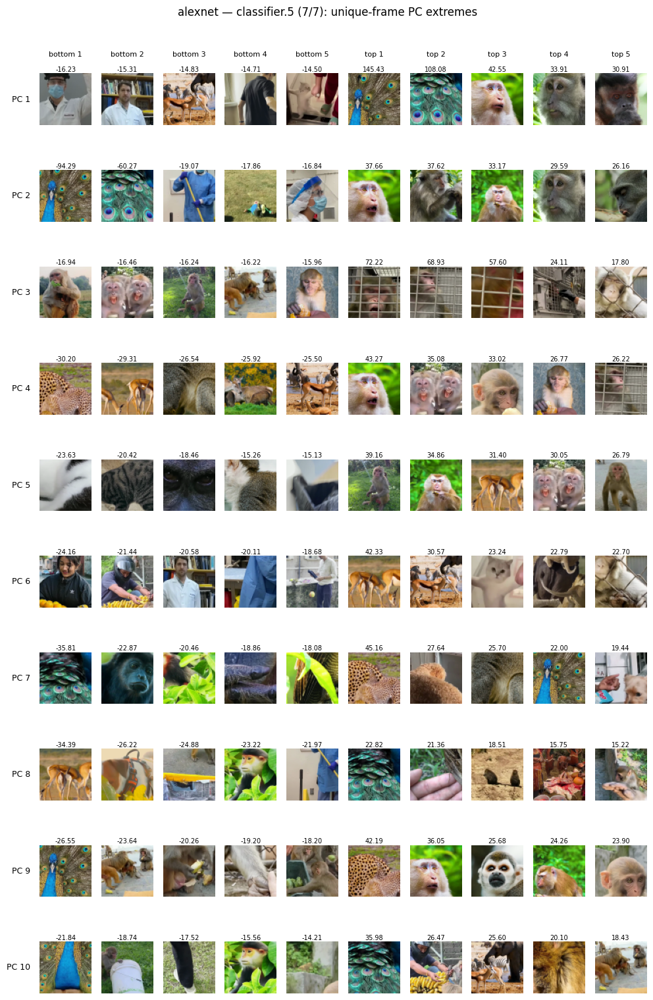

In [7]:
extreme_pc_indices = tuple(range(cfg.n_extreme_pcs))
for layer_index, feature_path in enumerate(feature_paths, start=1):
    scores, layer_name = load_pc_scores(
        feature_path, catalog, extreme_pc_indices,
    )
    bottom_indices, top_indices = get_pc_extreme_indices(
        scores=scores,
        unique_mask=catalog.unique_mask,
        video_indices=catalog.video_indices,
        n_extreme=cfg.n_extreme_frames,
    )
    selected_extreme_indices = np.concatenate([
        bottom_indices, top_indices,
    ], axis=1)
    for pc_selected_indices in selected_extreme_indices:
        selected_video_indices = catalog.video_indices[pc_selected_indices]
        if len(np.unique(selected_video_indices)) != len(selected_video_indices):
            raise RuntimeError(f"Repeated source movie in {layer_name} extremes.")
        # end if a source movie repeats
    # end for PC
    fig, _ = plot_pc_extremes(
        scores=scores,
        images=catalog.images,
        bottom_indices=bottom_indices,
        top_indices=top_indices,
        layer_name=(
            f"{cfg.model_name} — {layer_name} "
            f"({layer_index}/{len(feature_paths)})"
        ),
    )
    plt.show()
    plt.close(fig)
# end for feature_path

## Dense view of one target model and layer

The selected frames span each movie's unique-frame timeline approximately evenly, including its beginning and end.

Displayed 1,000 frames.


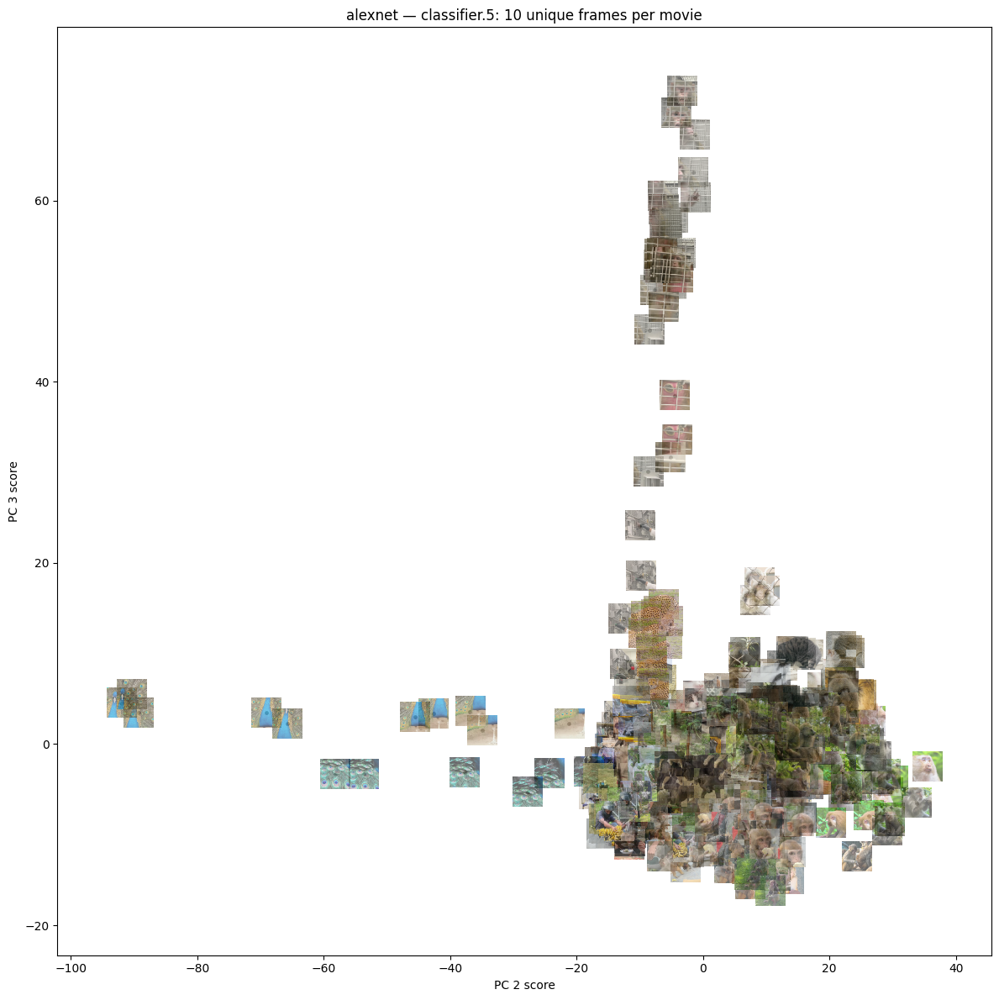

In [21]:
target_scores, loaded_target_layer = load_pc_scores(
    target_feature_path, catalog, cfg.pc_indices,
)
dense_indices = select_even_unique_frames(
    catalog, frames_per_video=cfg.dense_frames_per_video,
)

fig, _ = plot_image_scatter(
    coordinates=target_scores[dense_indices],
    images=catalog.images[dense_indices],
    pc_indices=cfg.pc_indices,
    title=(
        f"{target_model_name} — {loaded_target_layer}: "
        f"{cfg.dense_frames_per_video} unique frames per movie"
    ),
    image_zoom=cfg.dense_scatter_image_size,
    image_alpha=cfg.dense_scatter_image_alpha,
    figsize=(12, 12),
)
print(f"Displayed {len(dense_indices):,} frames.")
plt.show()